In [1]:
import geopandas as gpd
from pathlib import Path
import os
import numpy as np
from pyproj import Transformer
import requests
import time
import matplotlib.pyplot as plt

# I. Wild Fire Area Analysis

In [2]:
REPO_ROOT = Path(os.getcwd()).parent
DATA_PATH  = REPO_ROOT / "data" / "backtest" / "hist_data.parquet"

<Axes: ylabel='Frequency'>

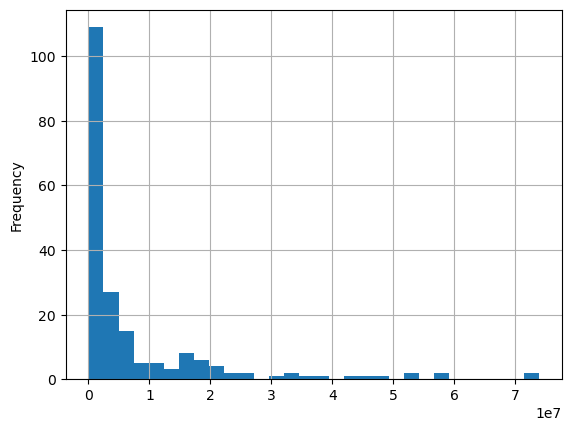

In [3]:
gdf = gpd.read_parquet(DATA_PATH)

gdf_metric = gdf.to_crs(epsg=2154)

areas = gdf_metric.geometry.area

areas.plot.hist(bins= 30, grid = True)

In [9]:
area_data = (gdf.assign(polygon_area = gdf.geometry.area)[["wildfire_id", "prop_step","polygon_area"]]
            .set_index(["wildfire_id", "prop_step"]))

gdf = gdf.merge(area_data, how = 'left', on = ["wildfire_id", "prop_step"])

In [10]:
gdf[["wildfire_id", 'prop_step', 'polygon_area']].query("wildfire_id == 45")

,wildfire_id,prop_step,polygon_area
170,45,0,3.136548e+00
171,45,1,5.548240e+06
172,45,2,1.873395e+07
173,45,3,3.326883e+07
174,45,4,3.605958e+07
175,45,5,4.342728e+07
176,45,6,5.850543e+07


In [11]:
gdf["wildfire_id"].value_counts()

wildfire_id
1     7
45    7
6     6
20    5
4     5
7     5
10    5
12    5
17    5
30    5
35    5
44    5
3     4
16    4
15    4
18    4
25    4
26    4
27    4
28    4
31    4
34    4
37    4
41    4
42    4
50    4
51    4
2     3
5     3
8     3
9     3
11    3
13    3
14    3
19    3
21    3
22    3
23    3
24    3
29    3
32    3
33    3
36    3
38    3
39    3
40    3
43    3
46    3
47    3
48    3
49    3
52    3
Name: count, dtype: int64

In [4]:
%cd ..
from simulators.backtest import FireForestViz, FireForestVizMatrix
%cd notebooks 

/home/perann/Bureau/MVA/Interactions/interactions
/home/perann/Bureau/MVA/Interactions/interactions/notebooks


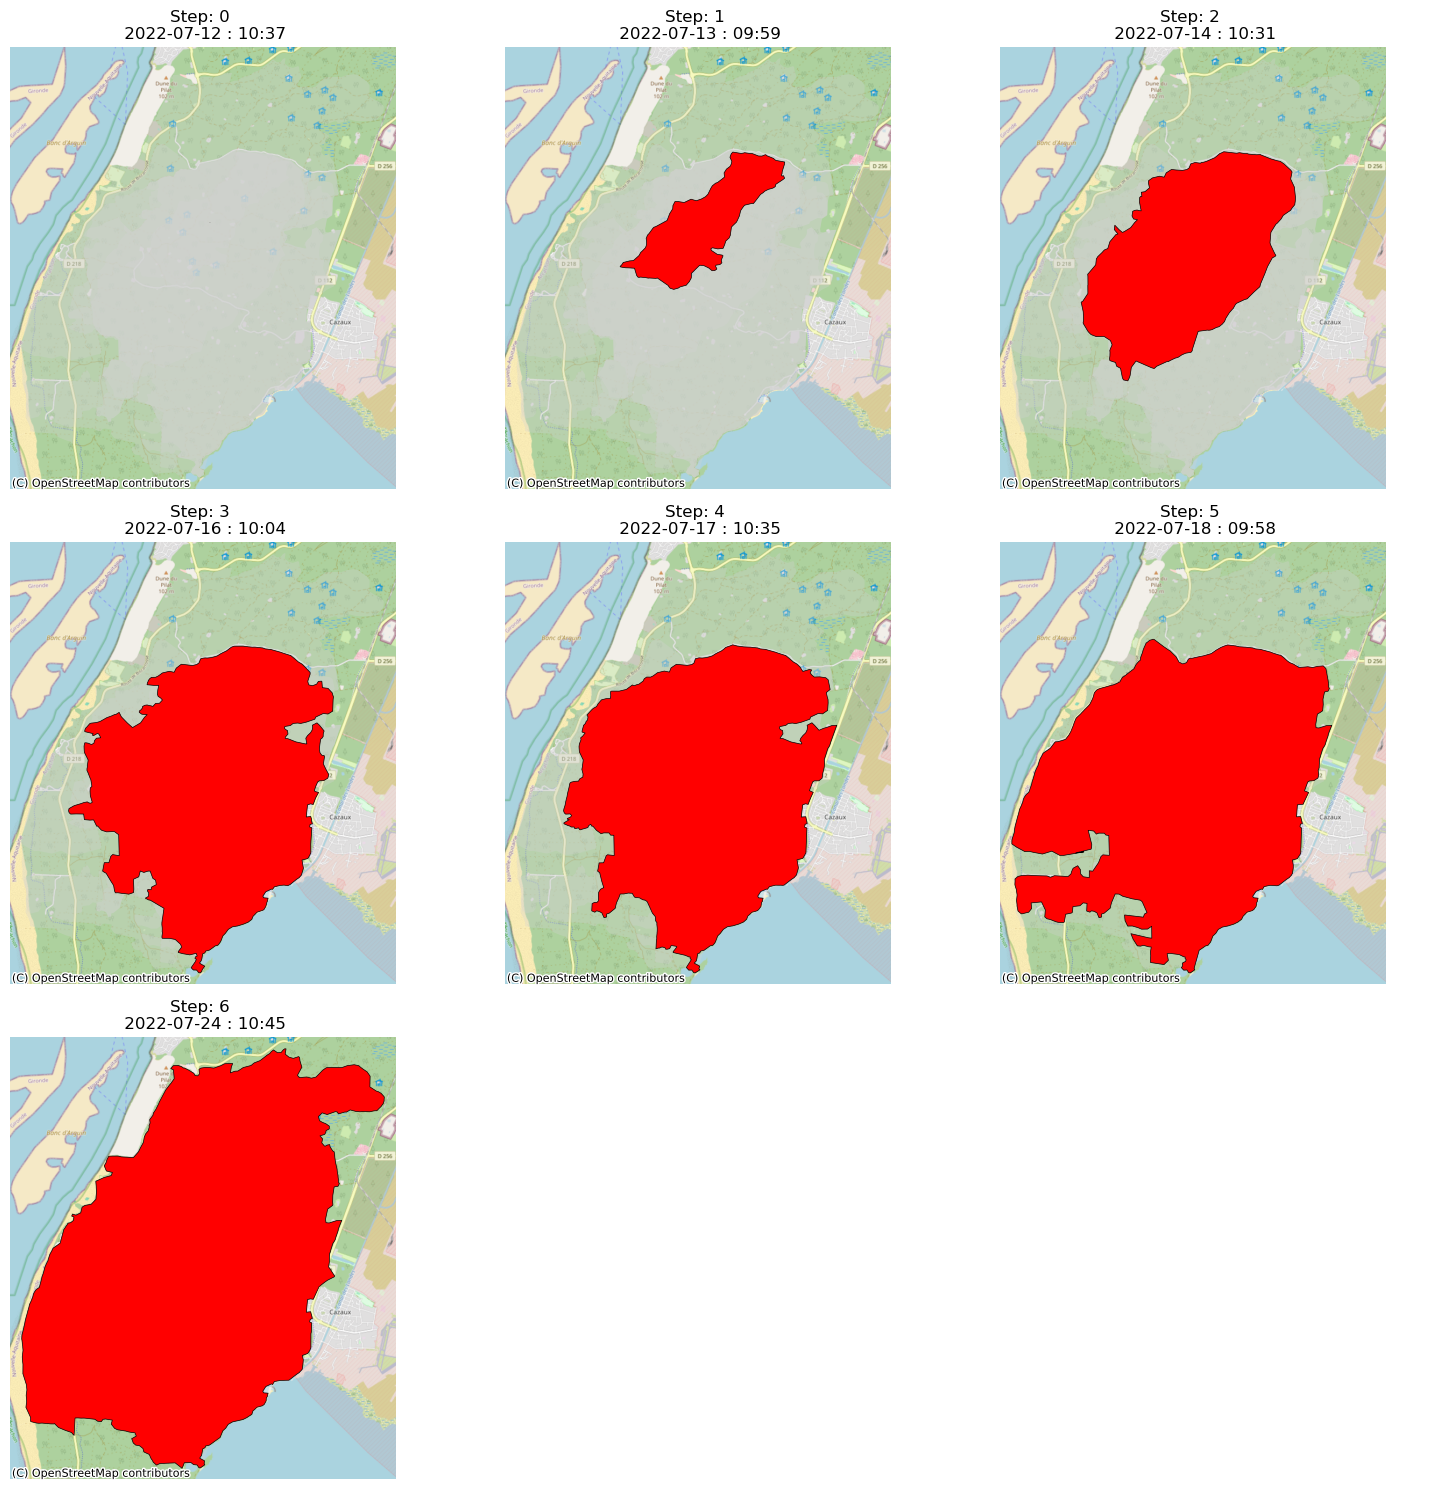

In [5]:
FireForestViz(45)

In [11]:
grid_x, grid_y = generate_covering_grid(45, 400, 200)

# II. Getting multiple data

In [21]:
def get_weather_grid(lat_flat, lon_flat, height, width, date_str, hour_idx=10):
    temps = []
    wind_speeds = []
    wind_dirs = []
    chunk_size = 50 
    i = 0
    
    print(f"Récupération météo pour le {date_str} à {hour_idx}h...")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        url = (f"https://archive-api.open-meteo.com/v1/archive?"
               f"latitude={lats_str}&longitude={lons_str}&"
               f"start_date={date_str}&end_date={date_str}&"
               f"hourly=temperature_2m,wind_speed_10m,wind_direction_10m&"
               f"timezone=auto")
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                for point_data in data:
                    temps.append(point_data['hourly']['temperature_2m'][hour_idx])
                    wind_speeds.append(point_data['hourly']['wind_speed_10m'][hour_idx])
                    wind_dirs.append(point_data['hourly']['wind_direction_10m'][hour_idx])
                
                i += chunk_size
                print(f"Météo : {len(temps)}/{len(lat_flat)} points.")
                time.sleep(0.5)
                
            elif response.status_code == 429:
                print("Limite API. Pause 62s...")
                time.sleep(62)
            else:
                print(f"Erreur : {data.get('reason')}")
                break
        except Exception as e:
            print(f"Erreur connexion : {e}")
            time.sleep(5)

    res_temps = np.flipud(np.array(temps).reshape((height, width)))
    res_wind_speed = np.flipud(np.array(wind_speeds).reshape((height, width)))
    res_wind_dir = np.flipud(np.array(wind_dirs).reshape((height, width)))
    
    return res_temps, res_wind_speed, res_wind_dir

In [22]:
gdf[gdf.wildfire_id == 45][["date", "prop_step"]]

,date,prop_step
568,2022-07-12 10:37:25,0
569,2022-07-13 09:59:05,1
570,2022-07-14 10:31:49,2
572,2022-07-16 10:04:17,3
573,2022-07-17 10:35:24,4
574,2022-07-18 09:58:39,5
580,2022-07-24 10:45:44,6


In [ ]:

transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
lon_flat, lat_flat = transformer.transform(grid_x.flatten(), grid_y.flatten())

height, width = grid_x.shape

dates = gdf[gdf.wildfire_id == 45]["date"].dt.strftime("%Y-%m-%d").unique()

for date in dates[1:]:
    m_temp, m_wind_v, m_wind_d = get_weather_grid(lat_flat, lon_flat, height, width, date, 10)
    
    np.save(BACKTEST_DATA_PATH / f"{date}_temperature.npy", m_temp)
    np.save(BACKTEST_DATA_PATH / f"{date}_wind_val.npy", m_wind_v)
    np.save(BACKTEST_DATA_PATH / f"{date}_wind_direction.npy", m_wind_d)

Récupération météo pour le 2022-07-13 à 10h...
Météo : 50/2916 points.
Météo : 100/2916 points.
Météo : 150/2916 points.


KeyboardInterrupt: 

In [ ]:
def get_humidity_grid(lat_flat, lon_flat, height, width, date_str, hour_idx=10):
    """
    Récupère la grille d'humidité relative (en %) pour une date et une heure données.
    """
    humidities = []
    chunk_size = 50 
    i = 0
    
    print(f"💧 Récupération humidité pour le {date_str} à {hour_idx}h...")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        # URL adaptée avec le paramètre relative_humidity_2m
        url = (f"https://archive-api.open-meteo.com/v1/archive?"
               f"latitude={lats_str}&longitude={lons_str}&"
               f"start_date={date_str}&end_date={date_str}&"
               f"hourly=relative_humidity_2m&"
               f"timezone=auto")
        
        try:
            response = requests.get(url)
            
            if response.status_code == 200:
                data = response.json()
                
                # Open-Meteo renvoie une liste si plusieurs coordonnées sont demandées
                if isinstance(data, list):
                    for point_data in data:
                        humidities.append(point_data['hourly']['relative_humidity_2m'][hour_idx])
                else:
                    # Cas où un seul point est renvoyé (si chunk_size=1 par exemple)
                    humidities.append(data['hourly']['relative_humidity_2m'][hour_idx])
                
                i += chunk_size
                print(f"Humidité : {len(humidities)}/{len(lat_flat)} points récupérés.")
                time.sleep(0.5) # Pause légère pour respecter les limites
                
            elif response.status_code == 429:
                print("\n[!] Limite API atteinte. Pause de 62 secondes...")
                time.sleep(62)
            else:
                print(f"Erreur API inattendue : {response.status_code}")
                break
                
        except Exception as e:
            print(f"Erreur de connexion : {e}. Nouvelle tentative dans 5 secondes...")
            time.sleep(5)

    if len(humidities) >= len(lat_flat):
        res_humidity = np.array(humidities[:len(lat_flat)]).reshape((height, width))
        return np.flipud(res_humidity)
    else:
        print("⚠️ Données incomplètes pour l'humidité.")
        return None


matrix_humidity = get_humidity_grid(lat_flat, lon_flat, height, width, "2022-07-12", hour_idx=10)
np.save(BACKTEST_DATA_PATH / f"{date}_humidity.npy", matrix_humidity)

💧 Récupération humidité pour le 2022-07-12 à 10h...
Humidité : 50/2916 points récupérés.

[!] Limite API atteinte. Pause de 62 secondes...
Humidité : 100/2916 points récupérés.
Humidité : 150/2916 points récupérés.
Humidité : 200/2916 points récupérés.
Humidité : 250/2916 points récupérés.
Humidité : 300/2916 points récupérés.
Humidité : 350/2916 points récupérés.
Humidité : 400/2916 points récupérés.
Humidité : 450/2916 points récupérés.
Humidité : 500/2916 points récupérés.
Humidité : 550/2916 points récupérés.
Humidité : 600/2916 points récupérés.
Humidité : 650/2916 points récupérés.

[!] Limite API atteinte. Pause de 62 secondes...
Humidité : 700/2916 points récupérés.
Humidité : 750/2916 points récupérés.
Humidité : 800/2916 points récupérés.
Humidité : 850/2916 points récupérés.
Humidité : 900/2916 points récupérés.
Humidité : 950/2916 points récupérés.
Humidité : 1000/2916 points récupérés.
Humidité : 1050/2916 points récupérés.
Humidité : 1100/2916 points récupérés.
Humidité :

In [ ]:

def get_elevation_grid(lat_flat, lon_flat, height, width):
    elevations = []
    chunk_size = 50  
    i = 0
    
    print(f"Début de la récupération : {len(lat_flat)} points à traiter.")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        url = f"https://api.open-meteo.com/v1/elevation?latitude={lats_str}&longitude={lons_str}"
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                elevations.extend(data['elevation'])
                print(f"Succès : {len(elevations)}/{len(lat_flat)} points récupérés.")
                i += chunk_size
                time.sleep(1) 
                
            elif response.status_code == 429 or (data.get('error') and 'limit exceeded' in data.get('reason', '')):
                print(f"\n[!] Limite API atteinte au point {i}. Pause de 62 secondes...")
                time.sleep(62) 
            else:
                print(f"Erreur API inattendue : {data.get('reason')}")
                break
                
        except Exception as e:
            print(f"Erreur de connexion : {e}. Nouvelle tentative dans 5 secondes...")
            time.sleep(5)

   
    if len(elevations) >= len(lat_flat):
        # On s'assure d'avoir la taille exacte (au cas où le dernier chunk dépasse)
        final_elev = np.array(elevations[:len(lat_flat)]).reshape((height, width))
        # On inverse le sens pour que le haut de la matrice soit le Nord
        return np.flipud(final_elev)
    else:
        return None


matrix_elevation = get_elevation_grid(lat_flat, lon_flat, height, width)
#np.save(BACKTEST_DATA_PATH / "altitude.npy", matrix_elevation)

NameError: name 'lat_flat' is not defined

In [ ]:
import osmnx as ox
from shapely.geometry import box

def get_osm_tag_matrix(wildfire_id, resolution, margin, gdf):
    """
    Génère une matrice numpy binaire (1: forêt, 0: autre) parfaitement 
    alignée avec la grille de simulation.
    """
    fire_area = gdf[gdf.wildfire_id == wildfire_id]
    if fire_area.empty:
        return None

    minx, miny, maxx, maxy = fire_area.total_bounds
    minx -= margin
    miny -= margin
    maxx += margin
    maxy += margin

    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)
    
    x_coords = [minx + i * resolution for i in range(width)]
    y_coords = [miny + i * resolution for i in range(height)]
    
    polygons = [box(x, y, x + resolution, y + resolution) 
                for y in reversed(y_coords) for x in x_coords]
    grid_gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=gdf.crs)

    grid_4326 = grid_gdf.to_crs(epsg=4326)
    study_area_polygon = box(*grid_4326.total_bounds)
    
    tags = {"landuse": True, "natural": True}
    
    try:
        features = ox.features_from_polygon(study_area_polygon, tags=tags)
        
        if features.empty:

            return np.zeros((height, width), dtype=int)
        
        features = features.to_crs(gdf.crs)
        features['tag'] = features['landuse'].fillna(features['natural']).fillna("unknown")
        
    except Exception as e:
        print(f"Erreur OSM : {e}")
        return np.zeros((height, width), dtype=int)

    joined = gpd.sjoin(grid_gdf, features[['geometry', 'tag']], how="left", predicate="intersects")
    

    tag_series = joined.groupby(joined.index)['tag'].first().fillna("empty")
    raw_tags = tag_series.to_numpy(dtype=object).reshape((height, width))

    
    return raw_tags

matrix = get_osm_tag_matrix(wildfire_id=45, resolution=200, margin=400, gdf=gdf)
np.save(BACKTEST_DATA_PATH / "ground_matrix.npy", matrix)

## IV. Testing Cellular automaton

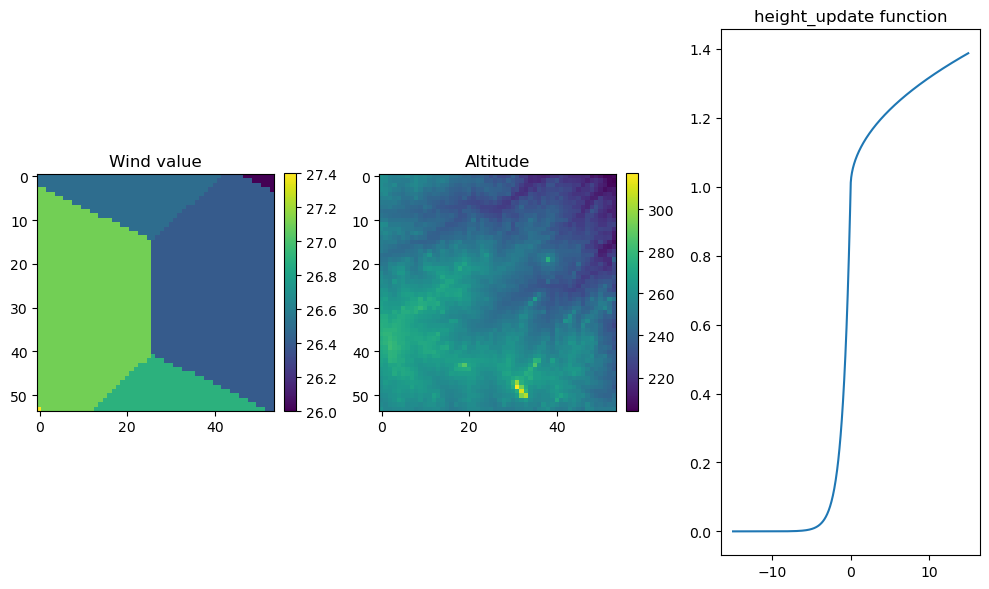

In [10]:
BACKTEST_DATA_PATH = REPO_ROOT / "data" / "backtest" / "fire_example_45"
BACKTEST_DATA_PATH.mkdir(parents=True, exist_ok=True)

def generate_covering_grid(wildfire_id : int, margin : int, resolution : int):
    
    minx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[0] - margin
    miny = gdf[gdf.wildfire_id == wildfire_id].total_bounds[1] - margin
    maxx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[2] + margin
    maxy = gdf[gdf.wildfire_id == wildfire_id].total_bounds[3] + margin

    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)

    x_centers = minx + (np.arange(width) * resolution) + (resolution / 2)
    y_centers = miny + (np.arange(height) * resolution) + (resolution / 2)

    grid_x, grid_y = np.meshgrid(x_centers, y_centers)

    return grid_x, grid_y


grid_x, grid_y = generate_covering_grid(45, 400, 200)
height, width = grid_x.shape

wind_grid = np.load(BACKTEST_DATA_PATH / "2022-07-12_wind_val.npy")
altitude = np.load(BACKTEST_DATA_PATH /"altitude.npy")

def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10 
    
    
fig, ax = plt.subplots(1,3, figsize = (10, 6))

im0 = ax[0].imshow(wind_grid, cmap= "viridis")
ax[0].set_title("Wind value")
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)


im1 = ax[1].imshow(altitude, cmap= "viridis")
ax[1].set_title("Altitude")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

x = np.linspace(-15, 15, 1000)
y = [height_update(val) for val in x]
ax[2].plot(x,y)
ax[2].set_title("height_update function")

plt.tight_layout() 
plt.show()


In [17]:
m = np.min(wind_grid)
M = np.max(wind_grid)

scaled_wind = (wind_grid - m)/(M-m) + 1

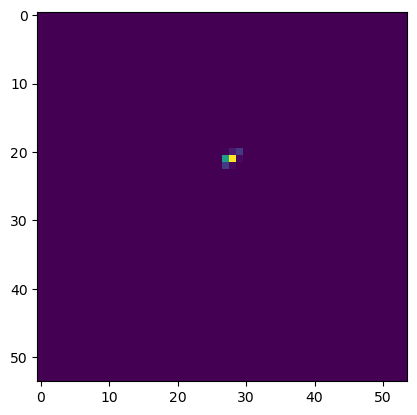

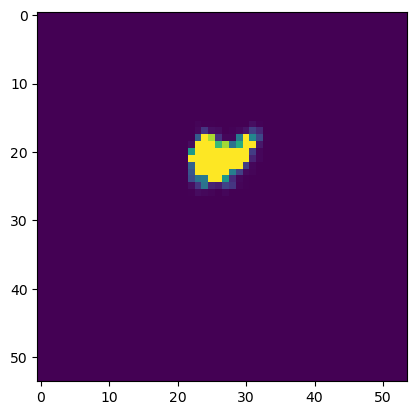

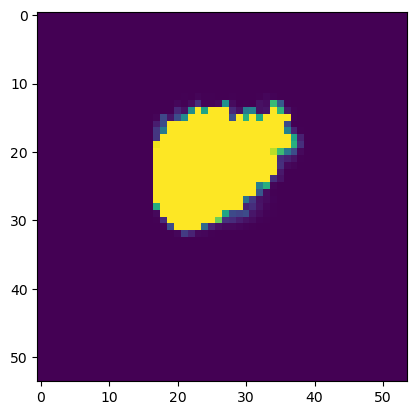

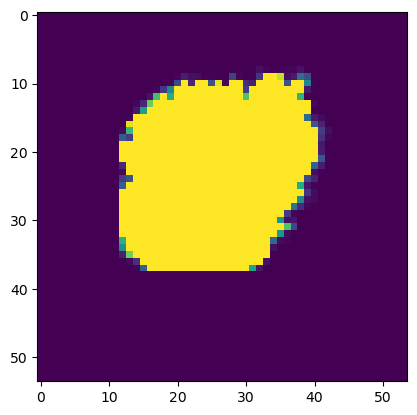

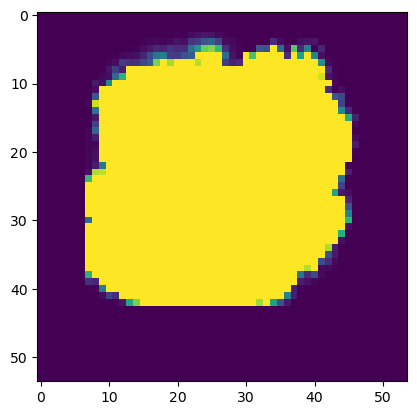

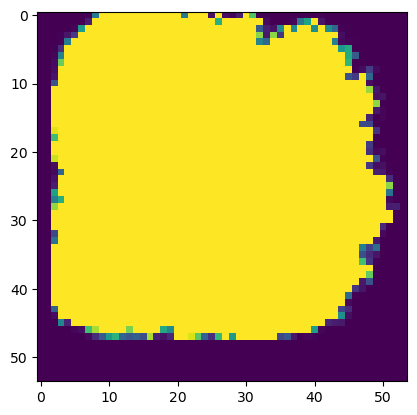

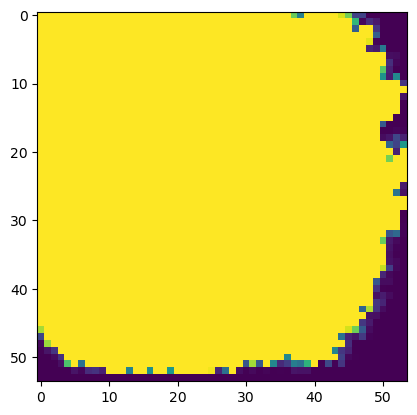

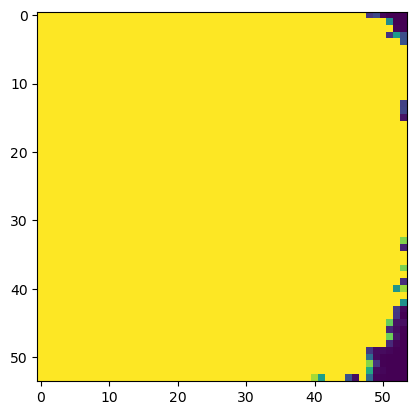

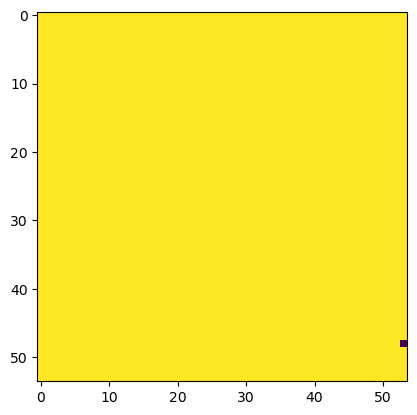

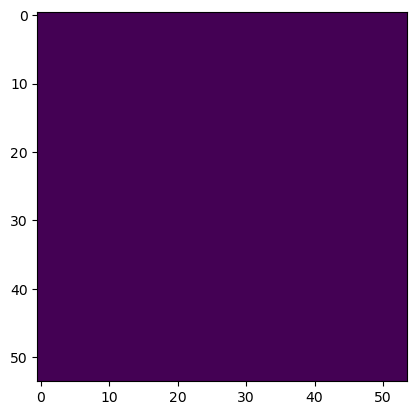

In [18]:
Model = CellularAutomaton(height, width,scaled_wind, altitude, height_update)
Model.initialize_ignition([(start_row, start_col)], [0.01])

current_state = Model.get_state()

for step in range(50):
    Model.evolve()
    if step % 5 == 0:
        current_state = Model.get_state()
        plt.imshow(current_state)
        plt.show()

# V. Real Firepropagation into matrix

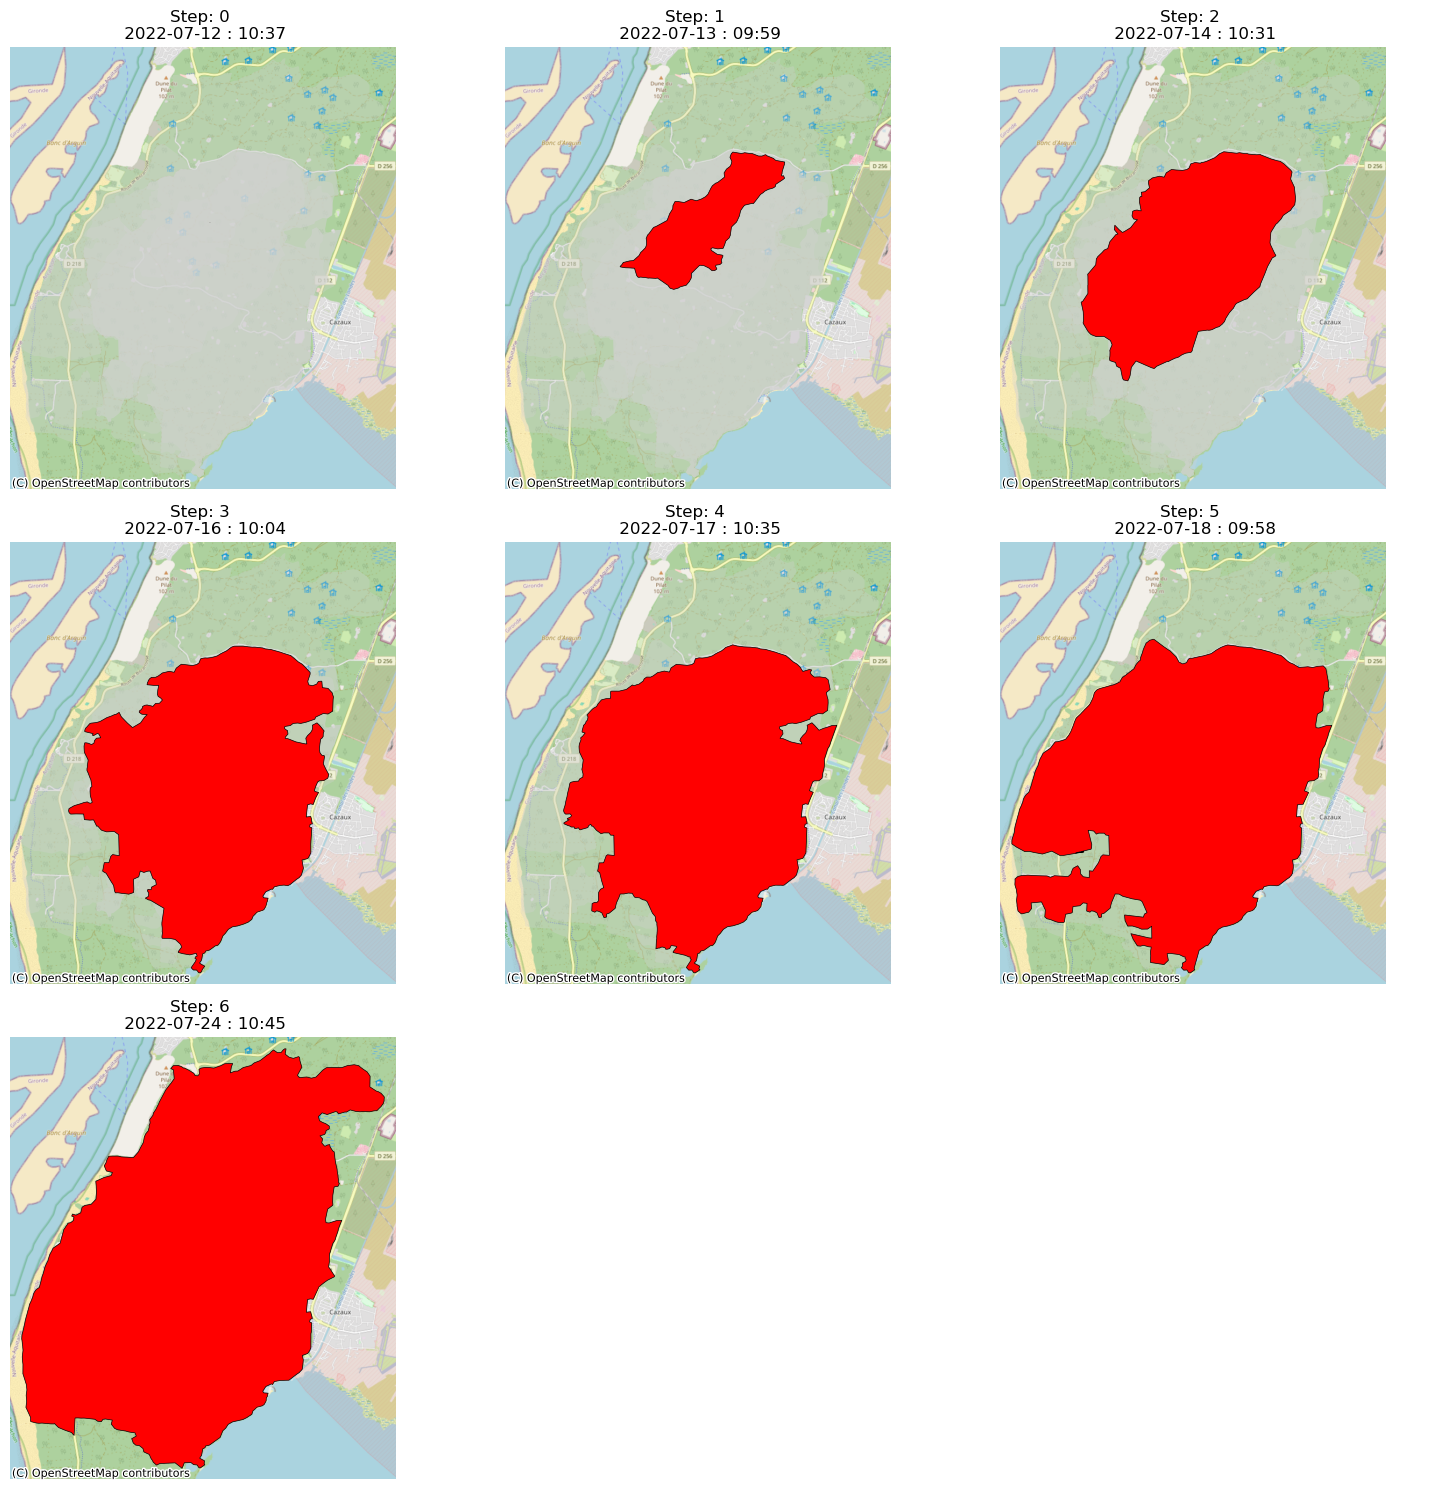

In [11]:
FireForestViz(45)

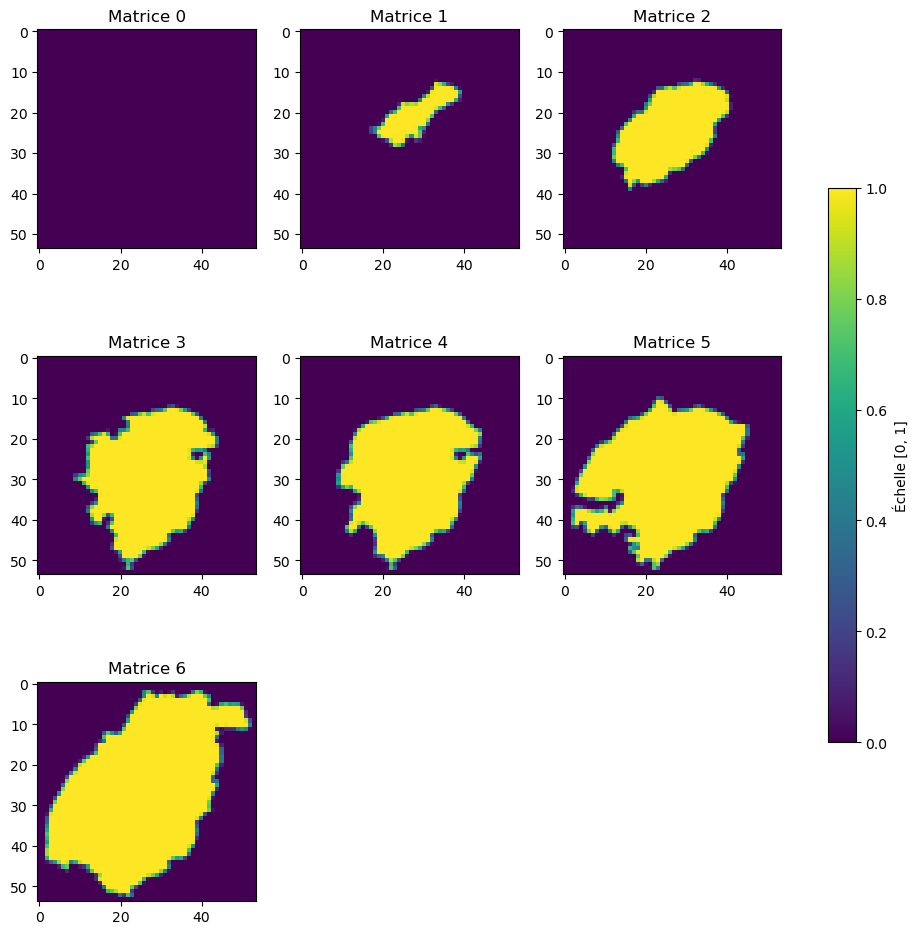

In [12]:
FireForestVizMatrix(45, 400, 200, gdf)

In [ ]:
import osmnx as ox
from shapely.geometry import box

def get_osm_tag_matrix(wildfire_id, resolution, margin, gdf):
    """
    Génère une matrice numpy binaire (1: forêt, 0: autre) parfaitement 
    alignée avec la grille de simulation.
    """
    fire_area = gdf[gdf.wildfire_id == wildfire_id]
    if fire_area.empty:
        return None

    minx, miny, maxx, maxy = fire_area.total_bounds
    minx -= margin
    miny -= margin
    maxx += margin
    maxy += margin

    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)
    
    x_coords = [minx + i * resolution for i in range(width)]
    y_coords = [miny + i * resolution for i in range(height)]
    
    polygons = [box(x, y, x + resolution, y + resolution) 
                for y in reversed(y_coords) for x in x_coords]
    grid_gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=gdf.crs)

    grid_4326 = grid_gdf.to_crs(epsg=4326)
    study_area_polygon = box(*grid_4326.total_bounds)
    
    tags = {"landuse": True, "natural": True}
    
    try:
        features = ox.features_from_polygon(study_area_polygon, tags=tags)
        
        if features.empty:

            return np.zeros((height, width), dtype=int)
        
        features = features.to_crs(gdf.crs)
        features['tag'] = features['landuse'].fillna(features['natural']).fillna("unknown")
        
    except Exception as e:
        print(f"Erreur OSM : {e}")
        return np.zeros((height, width), dtype=int)

    joined = gpd.sjoin(grid_gdf, features[['geometry', 'tag']], how="left", predicate="intersects")
    

    tag_series = joined.groupby(joined.index)['tag'].first().fillna("empty")
    raw_tags = tag_series.to_numpy(dtype=object).reshape((height, width))

    
    return raw_tags

matrix = get_osm_tag_matrix(wildfire_id=45, resolution=200, margin=400, gdf=gdf)
np.save(BACKTEST_DATA_PATH / "ground_matrix.npy", matrix)

# VII. Cellular automaton 

In [ ]:
from matplotlib.colors import ListedColormap
from simulators.CellularAutomaton import CellularAutomaton

def compute_start_point_coord(wildfire_id: int, margin: int, resolution: int):

    fire_data = gdf[gdf.wildfire_id == wildfire_id]
    total_bounds = fire_data.total_bounds
    minx = total_bounds[0] - margin
    maxy = total_bounds[3] + margin 

    start_geom = fire_data.sort_values('prop_step').iloc[0].geometry.centroid
    start_x, start_y = start_geom.x, start_geom.y

    col_idx = int((start_x - minx) // resolution)    
    row_idx = int((maxy - start_y) // resolution)

    return row_idx, col_idx


def generate_covering_grid(wildfire_id : int, margin : int, resolution : int):
    
    minx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[0] - margin
    miny = gdf[gdf.wildfire_id == wildfire_id].total_bounds[1] - margin
    maxx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[2] + margin
    maxy = gdf[gdf.wildfire_id == wildfire_id].total_bounds[3] + margin

    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)

    x_centers = minx + (np.arange(width) * resolution) + (resolution / 2)
    y_centers = miny + (np.arange(height) * resolution) + (resolution / 2)

    grid_x, grid_y = np.meshgrid(x_centers, y_centers)

    return grid_x, grid_y

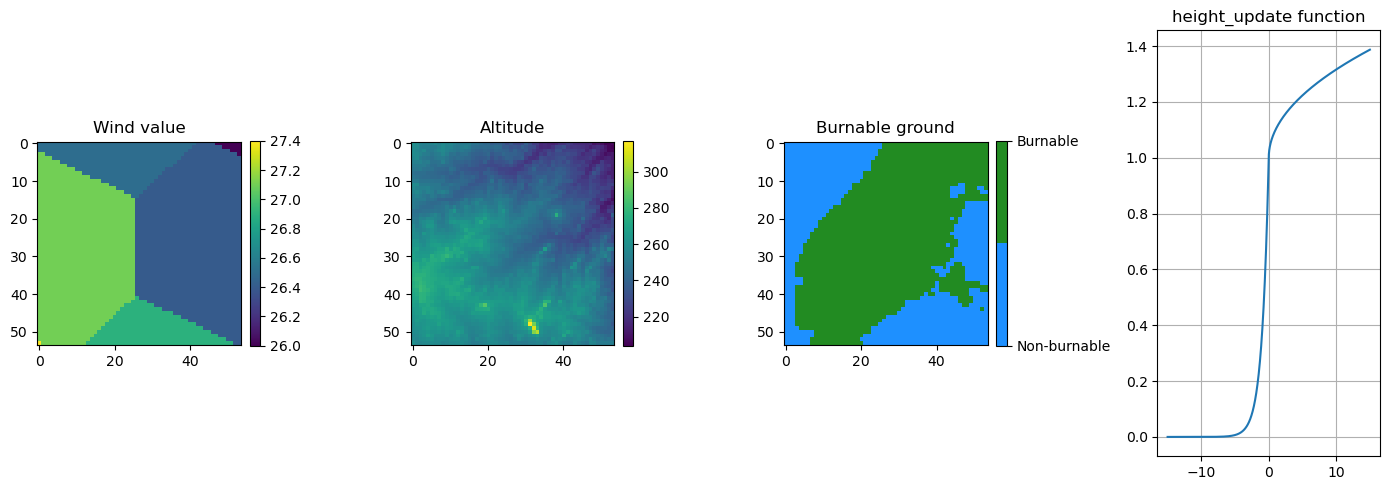

In [96]:
start_row, start_col = compute_start_point_coord(45, 400, 200)

grid_x, grid_y = generate_covering_grid(45, 400, 200)
height, width = grid_x.shape

wind_grid = np.load(BACKTEST_DATA_PATH / "2022-07-12_wind_val.npy")
altitude = np.load(BACKTEST_DATA_PATH / "altitude.npy")
ground_matrix = np.load(BACKTEST_DATA_PATH / "ground_matrix.npy", allow_pickle=True)
binary_ground = ((ground_matrix == 'industrial')|(ground_matrix == "residential")|(ground_matrix == "forest")|(ground_matrix == "tree")|(ground_matrix == "grass")).astype(int)

def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10 
    
    
fig, ax = plt.subplots(1,4, figsize = (14, 5))

im0 = ax[0].imshow(wind_grid, cmap= "viridis")
ax[0].set_title("Wind value")
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)


im1 = ax[1].imshow(altitude, cmap= "viridis")
ax[1].set_title("Altitude")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

cmap_custom = ListedColormap(['dodgerblue', 'forestgreen'])
im2 = ax[2].imshow(binary_ground, cmap=cmap_custom)
ax[2].set_title("Burnable ground")
cbar = fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04, ticks=[0, 1])
cbar.ax.set_yticklabels(['Non-burnable', 'Burnable'])

x = np.linspace(-15, 15, 1000)
y = [height_update(val) for val in x]
ax[3].plot(x,y)
ax[3].set_title("height_update function")
ax[3].grid()

plt.tight_layout() 
plt.show()


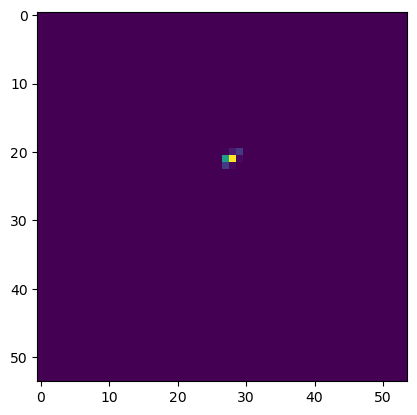

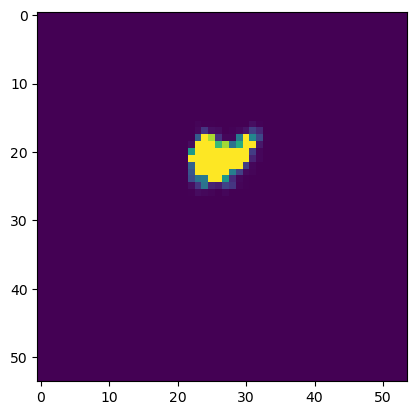

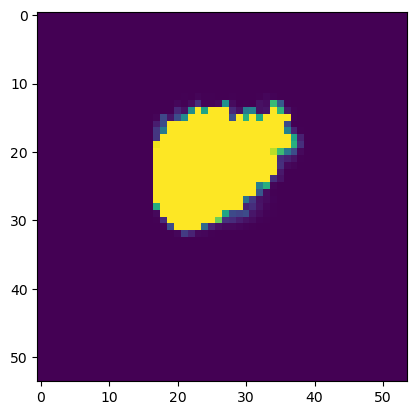

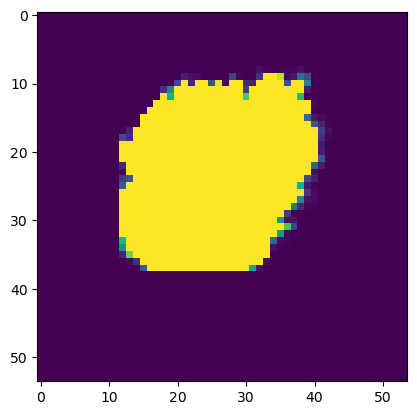

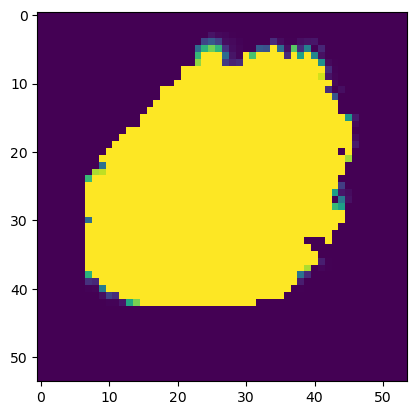

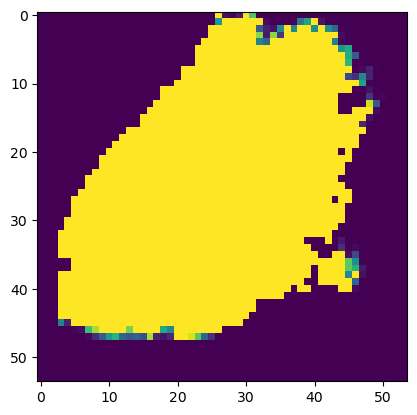

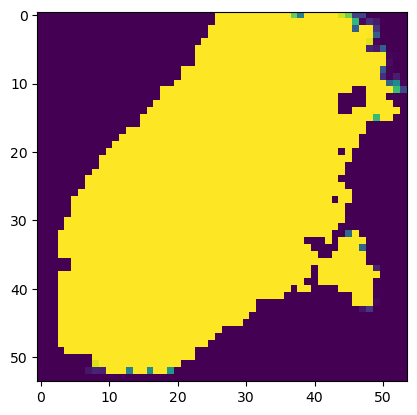

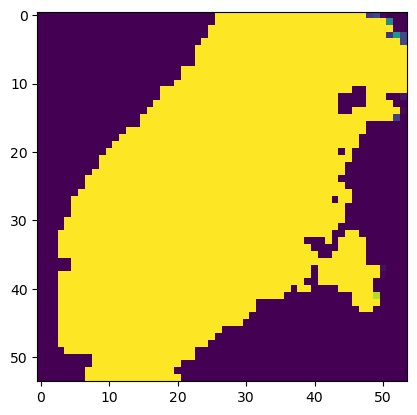

In [97]:
grid_x, grid_y = generate_covering_grid(45, 400, 200)
height, width = grid_x.shape

m = np.min(wind_grid)
M = np.max(wind_grid)

scaled_wind = (wind_grid - m)/(M-m) + 1

Model = CellularAutomaton(height, width, scaled_wind, altitude, height_update,binary_ground)

Model.initialize_ignition([(start_row, start_col)], [0.01])

current_state = Model.get_state()

ac_evol_states : list[np.ndarray] = [current_state]

for step in range(40):
    Model.evolve()
    ac_evol_states.append(Model.get_state())
    if step % 5 == 0:
        current_state = Model.get_state()
        plt.imshow(current_state)
        plt.show()

# VIII. Computing metrics

In [98]:
%cd ..
from simulators.metrics import FireMetrics
from simulators.backtest import generate_wildfire_propagation_grids
%cd notebooks


/home/perann/Bureau/MVA/Interactions/interactions
/home/perann/Bureau/MVA/Interactions/interactions/notebooks


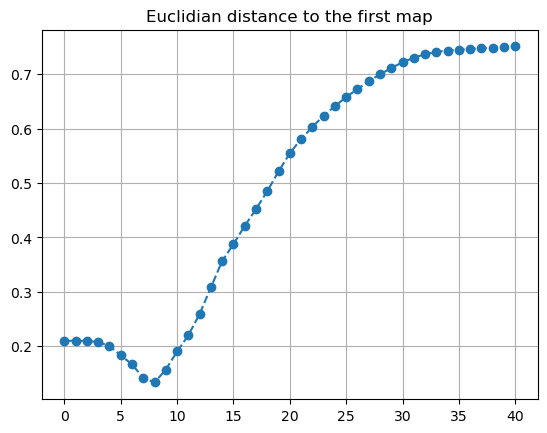

In [99]:
evol_grids = generate_wildfire_propagation_grids(45, 400, 200, gdf)
first_step = [evol_grids[1] for _ in range(len(ac_evol_states))]

MetricsComputer = FireMetrics(ac_evol_states, first_step, 0.5)

metrics_values = []
for t in range(len(ac_evol_states)):
    metrics = MetricsComputer.all_shape_metrics(t=t, t_tilde=t)
    metrics['step'] = t
    metrics_values.append(metrics)


fig, ax = plt.subplots()

x = np.arange(0, len(metrics_values))
y = [metric['l2_norm'] for metric in metrics_values]

ax.plot(x,y,'--o')
ax.set_title('Euclidian distance to the first map')
ax.grid()

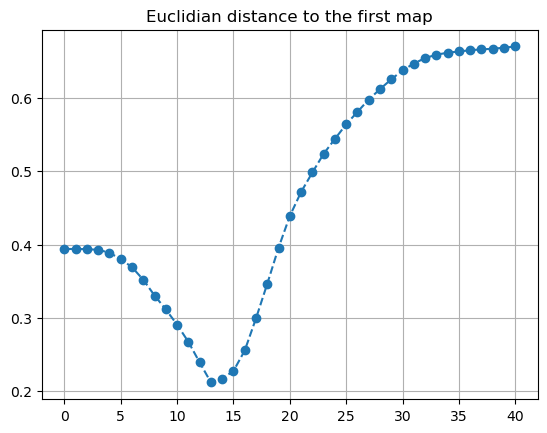

In [100]:
evol_grids = generate_wildfire_propagation_grids(45, 400, 200, gdf)
first_step = [evol_grids[2] for _ in range(len(ac_evol_states))]

MetricsComputer = FireMetrics(ac_evol_states, first_step, 0.5)

metrics_values = []
for t in range(len(ac_evol_states)):
    metrics = MetricsComputer.all_shape_metrics(t=t, t_tilde=t)
    metrics['step'] = t
    metrics_values.append(metrics)


fig, ax = plt.subplots()

x = np.arange(0, len(metrics_values))
y = [metric['l2_norm'] for metric in metrics_values]

ax.plot(x,y,'--o')
ax.set_title('Euclidian distance to the first map')
ax.grid()

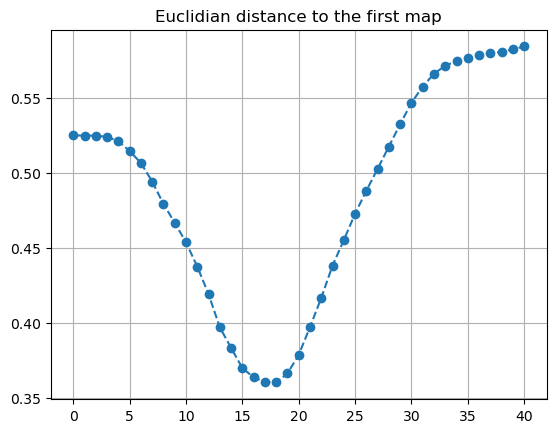

In [101]:
evol_grids = generate_wildfire_propagation_grids(45, 400, 200, gdf)
first_step = [evol_grids[3] for _ in range(len(ac_evol_states))]

MetricsComputer = FireMetrics(ac_evol_states, first_step, 0.5)

metrics_values = []
for t in range(len(ac_evol_states)):
    metrics = MetricsComputer.all_shape_metrics(t=t, t_tilde=t)
    metrics['step'] = t
    metrics_values.append(metrics)


fig, ax = plt.subplots()

x = np.arange(0, len(metrics_values))
y = [metric['l2_norm'] for metric in metrics_values]

ax.plot(x,y,'--o')
ax.set_title('Euclidian distance to the first map')
ax.grid()

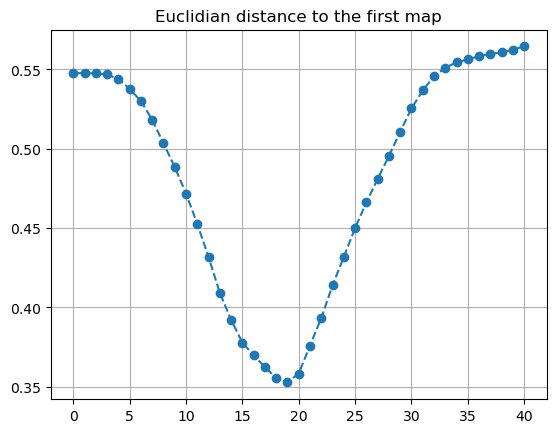

In [102]:
evol_grids = generate_wildfire_propagation_grids(45, 400, 200, gdf)
first_step = [evol_grids[4] for _ in range(len(ac_evol_states))]

MetricsComputer = FireMetrics(ac_evol_states, first_step, 0.5)

metrics_values = []
for t in range(len(ac_evol_states)):
    metrics = MetricsComputer.all_shape_metrics(t=t, t_tilde=t)
    metrics['step'] = t
    metrics_values.append(metrics)


fig, ax = plt.subplots()

x = np.arange(0, len(metrics_values))
y = [metric['l2_norm'] for metric in metrics_values]

ax.plot(x,y,'--o')
ax.set_title('Euclidian distance to the first map')
ax.grid()

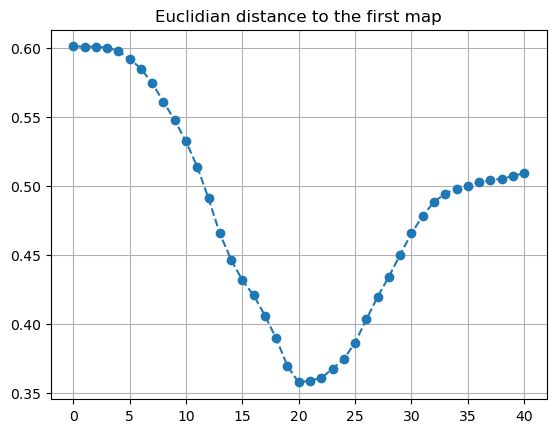

In [103]:
evol_grids = generate_wildfire_propagation_grids(45, 400, 200, gdf)
first_step = [evol_grids[5] for _ in range(len(ac_evol_states))]

MetricsComputer = FireMetrics(ac_evol_states, first_step, 0.5)

metrics_values = []
for t in range(len(ac_evol_states)):
    metrics = MetricsComputer.all_shape_metrics(t=t, t_tilde=t)
    metrics['step'] = t
    metrics_values.append(metrics)


fig, ax = plt.subplots()

x = np.arange(0, len(metrics_values))
y = [metric['l2_norm'] for metric in metrics_values]

ax.plot(x,y,'--o')
ax.set_title('Euclidian distance to the first map')
ax.grid()

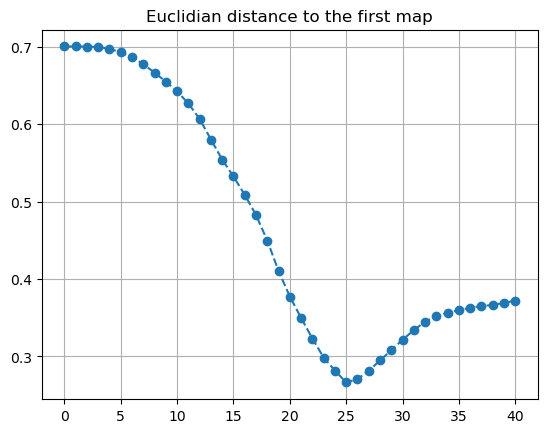

In [104]:
evol_grids = generate_wildfire_propagation_grids(45, 400, 200, gdf)
first_step = [evol_grids[6] for _ in range(len(ac_evol_states))]

MetricsComputer = FireMetrics(ac_evol_states, first_step, 0.5)

metrics_values = []
for t in range(len(ac_evol_states)):
    metrics = MetricsComputer.all_shape_metrics(t=t, t_tilde=t)
    metrics['step'] = t
    metrics_values.append(metrics)


fig, ax = plt.subplots()

x = np.arange(0, len(metrics_values))
y = [metric['l2_norm'] for metric in metrics_values]

ax.plot(x,y,'--o')
ax.set_title('Euclidian distance to the first map')
ax.grid()

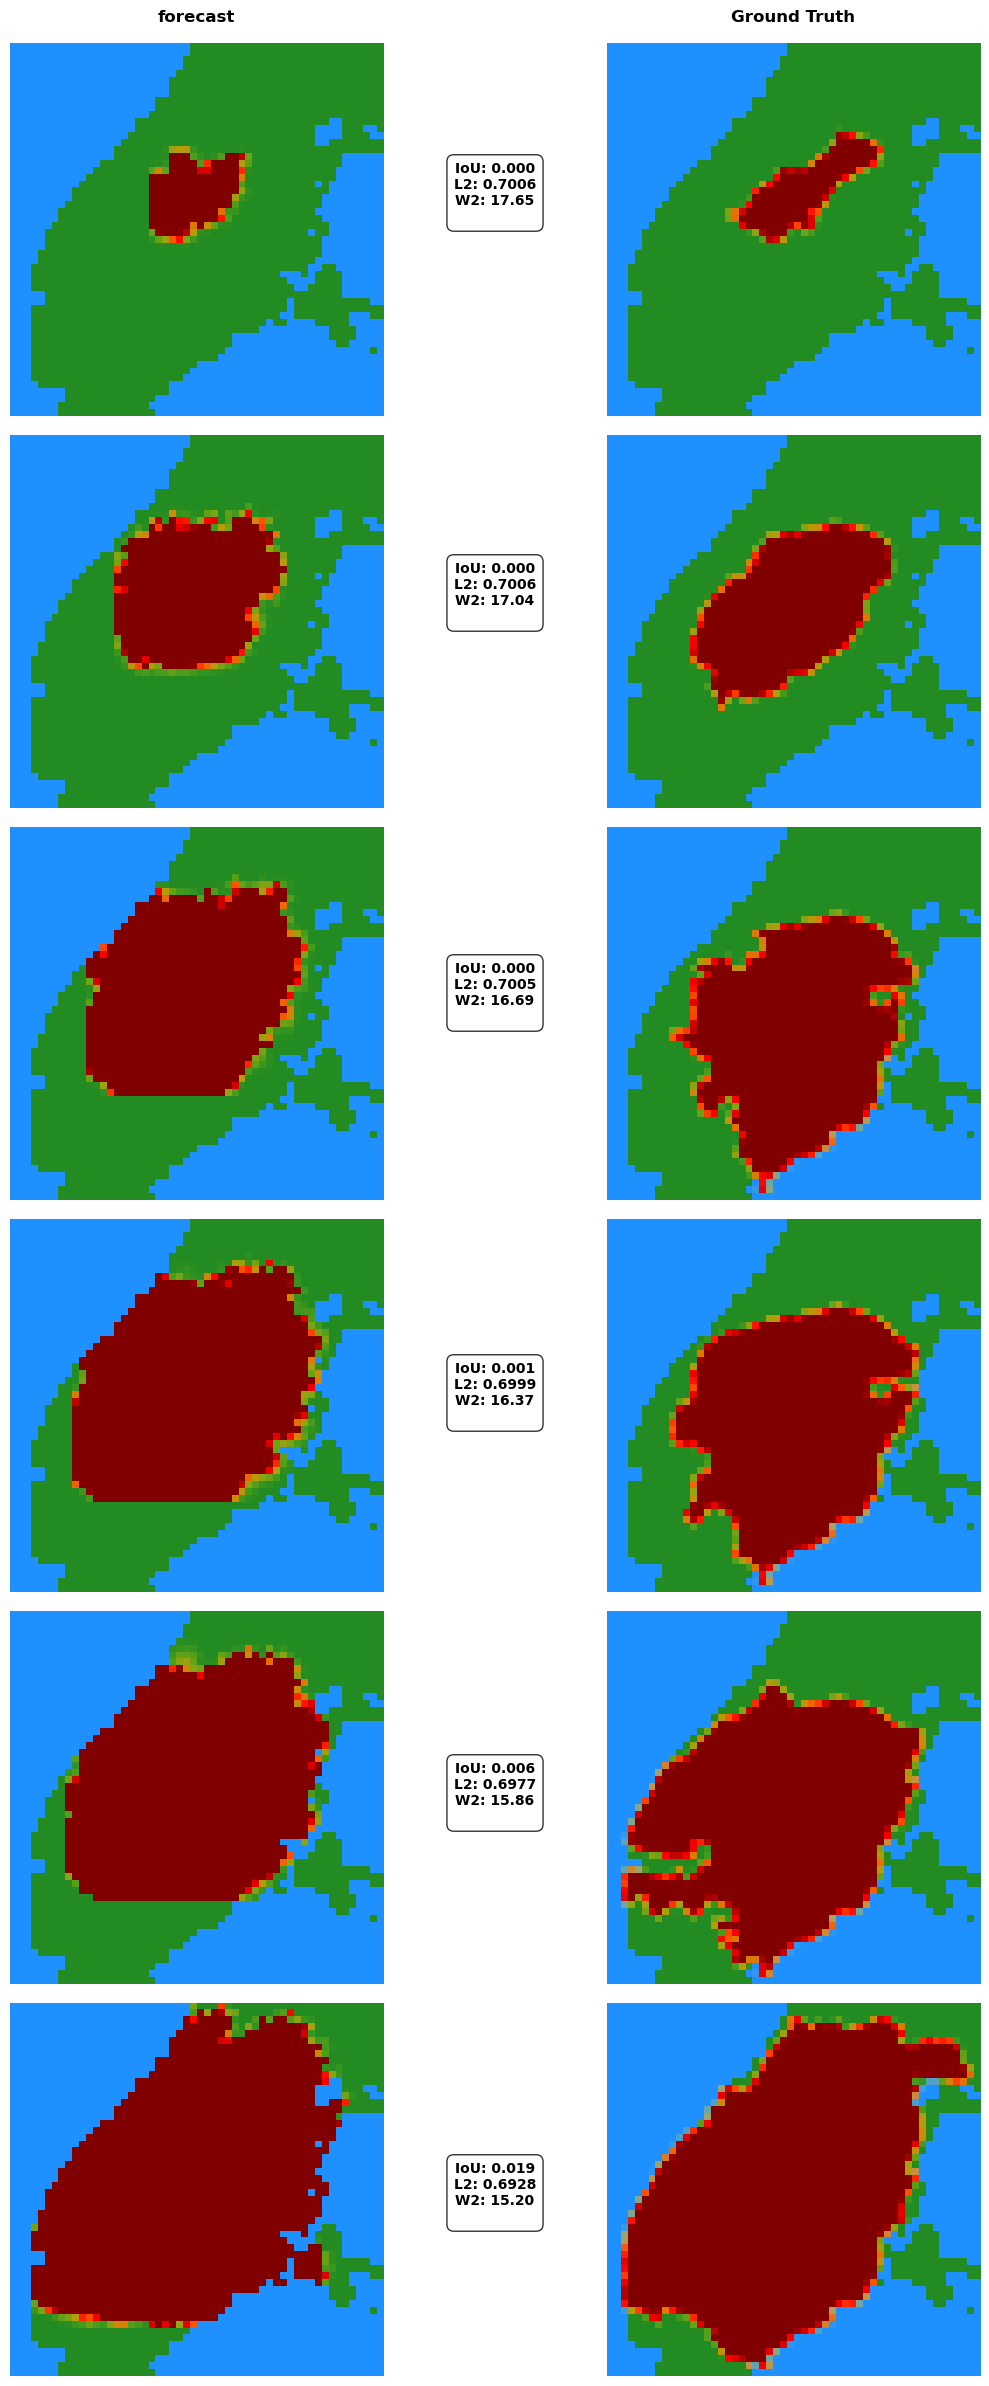

In [107]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

cmap_terrain = ListedColormap(['#1E90FF', '#228B22']) 
colors_fire = ["#FFFF00", "#FFA500", "#FF0000", "#800000"] 
cmap_fire = LinearSegmentedColormap.from_list("fire_hot", colors_fire)

best_fits_idx_filtered = best_fits_idx[1:]
best_grids_filtered = [ac_evol_states[k] for k in best_fits_idx_filtered]
evol_grids_filtered = evol_grids[1:]

n_rows = len(best_grids_filtered)
fig, ax = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))

for k, forecast in enumerate(best_grids_filtered):
    real_grid = evol_grids_filtered[k]
    
    for j, grid in enumerate([forecast, real_grid]):

        ax[k][j].imshow(binary_ground, cmap=cmap_terrain, interpolation='nearest')
        fire_display = np.copy(grid)
        alpha_mask = np.clip(fire_display * 2.0, 0, 1) 
        ax[k][j].imshow(fire_display, cmap=cmap_fire, alpha=alpha_mask)
        
        ax[k][j].set_axis_off()

    m = MetricsComputer.all_shape_metrics(k, k)
    h_val = f"{m['hausdorff']:.2f}" if m['hausdorff'] != float('inf') else "inf"
    metrics_text = (f"IoU: {m['iou']:.3f}\n"
                    f"L2: {m['l2_norm']:.4f}\n"
                    f"W2: {m['wasserstein2']:.2f}\n")
    
    y_pos = (n_rows - k - 0.5) / n_rows 
    fig.text(0.5, y_pos, metrics_text, va='center', ha='center', fontsize=10, 
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

    if k == 0:
        ax[k][0].set_title("forecast", pad=15, fontweight='bold')
        ax[k][1].set_title("Ground Truth", pad=15, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
plt.show()